In [1]:
import pandas as pd
import numpy as np
from astropy.table import Table
roots_tfm = '/home/julien/Documents/Etudes/Astrofisica/Master/TFM/Data'

In [2]:
df_tde = pd.read_csv(roots_tfm +'/TDE/TDE_match_UVOT_OM')

In [3]:
df_tde.head(20)

,col1_1,SRCNUM_1,SRCNUM_2,RA,DEC,POSERR,COUNT,col1_2,col2,col3,col4,MJD,Separation
0,2545521,2545522,0,182.199409,43.022292,0.346912,9,Dougie,TDE,12:08:47.87,+43:01:20.01,54848.0,0.786408
1,3220507,3220508,0,219.670713,37.659310,0.366845,2,PTF10iya,TDE,14:38:41.00,+37:39:33.60,55358.0,0.963911
2,6264505,0,64490,7.806580,85.008761,0.907158,3,2020mot,TDE,00:31:13.59,+85:00:31.96,59014.0,0.464776
3,6647918,0,447903,15.708270,-22.365846,0.508910,2,2022agi,TDE,01:02:50.01,-22:21:57.22,55372.0,0.765152
4,6700282,0,500267,16.890117,23.476272,0.524930,1,2018hco,TDE,01:07:33.61,+23:28:34.39,58395.0,0.592279
5,7179247,0,979232,53.697682,-26.326513,0.783955,2,DES14C1kia,TDE,03:34:47.49,-26:19:35.00,56972.0,0.979284
6,8515948,0,2315933,105.827631,23.029117,0.487151,1,2018lna,TDE,07:03:18.65,+23:01:44.70,58480.0,0.580632
7,8646045,0,2446030,119.227336,34.262107,0.608996,3,2018zr,TDE,07:56:54.53,+34:15:43.60,58183.0,0.624913
8,9212611,0,3012596,168.862285,18.110443,0.508140,2,NGC 3599,TDE,11:15:26.95,+18:06:37.33,52421.0,0.526456
9,9328594,0,3128579,180.400195,30.051576,0.598076,3,SDSSJ1201,TDE,12:01:36.03,+30:03:05.52,55357.0,0.447795


In [4]:
df_tde.shape

(20, 13)

In [5]:
df_tde.loc[:,'COUNT'].sum()

np.int64(57)

In [6]:
tuple(list(df_tde.loc[df_tde['SRCNUM_1']!= 0,'SRCNUM_1']))

(2545522, 3220508)

In [7]:
roots_tfm_extern = '/media/julien/TOSHIBA EXT/Copie_non_miroir/Master/TFM/Data'
import sqlite3 
con = sqlite3.connect(roots_tfm_extern + '/UVCatalogue_complete.db')
cursor = con.cursor()

In [8]:
from prettytable import from_db_cursor
sql_command = "SELECT SRCNUM, MJD, UVW2_FLUX, UVW1_FLUX, UVM2_FLUX, U_FLUX, V_FLUX, B_FLUX,"+ \
 "UVW2_FLUX_ERR from ENTRIES_UVOT LIMIT 2"
ans = cursor.execute(sql_command)
mytable = from_db_cursor(cursor)
print(mytable)

+--------+-------------------+-----------------------+-----------+------------------------+--------+--------+--------+------------------------+
| SRCNUM |        MJD        |       UVW2_FLUX       | UVW1_FLUX |       UVM2_FLUX        | U_FLUX | V_FLUX | B_FLUX |     UVW2_FLUX_ERR      |
+--------+-------------------+-----------------------+-----------+------------------------+--------+--------+--------+------------------------+
|   1    | 54973.74628472222 | 7.057068234939004e-16 |    None   | 1.4391411381672723e-16 |  None  |  None  |  None  | 1.0643398288988199e-17 |
|   2    | 54973.74628472222 | 3.489492846918224e-17 |    None   | 2.342524871296686e-17  |  None  |  None  |  None  | 2.6017930124138263e-18 |
+--------+-------------------+-----------------------+-----------+------------------------+--------+--------+--------+------------------------+


In [9]:
sql_command = "SELECT SRCNUM, MJD, UVW2_FLUX, UVW1_FLUX, UVM2_FLUX, U_FLUX, V_FLUX, B_FLUX,"+ \
 "UVW2_FLUX_ERR, UVW1_FLUX_ERR, UVM2_FLUX_ERR, U_FLUX_ERR, V_FLUX_ERR, B_FLUX_ERR from ENTRIES_UVOT where SRCNUM IN " \
+ str(tuple(list(df_tde.loc[df_tde['SRCNUM_1']!= 0,'SRCNUM_1'])))
ans_uvot = cursor.execute(sql_command).fetchall()

In [10]:
sql_command = "SELECT SRCNUM, MJD, UVW2_FLUX, UVW1_FLUX, UVM2_FLUX, U_FLUX, V_FLUX, B_FLUX,"+ \
 "UVW2_FLUX_ERR, UVW1_FLUX_ERR, UVM2_FLUX_ERR, U_FLUX_ERR, V_FLUX_ERR, B_FLUX_ERR from ENTRIES_OM where SRCNUM IN" \
+ str(tuple(list(df_tde.loc[df_tde['SRCNUM_2']!= 0,'SRCNUM_2'])))
ans_om = cursor.execute(sql_command).fetchall()

In [11]:
con.close()

In [12]:
results = []
list_keys =['MJD', 'UVW2_FLUX', 'UVW1_FLUX', 'UVM2_FLUX','U_FLUX', 'V_FLUX', 'B_FLUX', 'UVW2_FLUX_ERR', 'UVW1_FLUX_ERR', \
            'UVM2_FLUX_ERR','U_FLUX_ERR', 'V_FLUX_ERR', 'B_FLUX_ERR']
u=0
o=0
for tde in range(df_tde.shape[0]):

    for entrie in range(df_tde.loc[tde,'COUNT']):
        entries_dict ={}
        entries_dict['TDE_NAME'] = df_tde.loc[tde,'col1_2']
        entries_dict['RA'] = df_tde.loc[tde,'RA']
        entries_dict['DEC'] = df_tde.loc[tde,'DEC']
        
        if df_tde.loc[tde,'SRCNUM_1'] != 0:
            entries_dict['CAT'] = "UVOT"
            entries_dict['SRCNUM_1'] = ans_uvot[u][0]
            for j,key in enumerate(list_keys):
                entries_dict[key] = ans_uvot[u][j+1]
            u+=1
                      
        elif df_tde.loc[tde,'SRCNUM_2'] != 0: 
            entries_dict['CAT'] = "OM"
            entries_dict['SRCNUM_2'] = ans_om[o][0]
            for j,key in enumerate(list_keys):
                entries_dict[key] = ans_om[o][j+1]
            o+=1

        results.append(entries_dict)

In [13]:
ans_uvot[1]

(2545522,
 54882.01508101852,
 8.273338725769215e-17,
 6.613455904638246e-17,
 7.198878093921625e-17,
 8.218255776162574e-17,
 7.866271896675539e-17,
 1.0891126474738642e-16,
 1.1456304245710399e-17,
 9.200233645059795e-18,
 1.2484062094737122e-17,
 7.394551307415739e-18,
 1.0287106783743233e-17,
 8.441077057360678e-18)

In [14]:
df = pd.DataFrame(results, columns=['TDE_NAME', 'RA', 'DEC', 'CAT', 'MJD', 'UVW2_FLUX', 'UVW1_FLUX', 'UVM2_FLUX',\
                                    'U_FLUX', 'V_FLUX', 'B_FLUX', 'UVW2_FLUX_ERR', 'UVW1_FLUX_ERR', 'UVM2_FLUX_ERR', \
                                    'U_FLUX_ERR', 'V_FLUX_ERR', 'B_FLUX_ERR'])

In [15]:
df[df['TDE_NAME']=='ASASSN-14li']

,TDE_NAME,RA,DEC,CAT,MJD,UVW2_FLUX,UVW1_FLUX,UVM2_FLUX,U_FLUX,V_FLUX,B_FLUX,UVW2_FLUX_ERR,UVW1_FLUX_ERR,UVM2_FLUX_ERR,U_FLUX_ERR,V_FLUX_ERR,B_FLUX_ERR
30,ASASSN-14li,192.063447,17.774125,OM,57213.0,NaN,NaN,NaN,8.600623e-16,NaN,NaN,NaN,NaN,NaN,4.641967e-18,NaN,NaN
31,ASASSN-14li,192.063447,17.774125,OM,57912.0,NaN,6.837983e-16,NaN,8.322249e-16,NaN,NaN,NaN,1.064140e-17,NaN,8.305208e-18,NaN,NaN
32,ASASSN-14li,192.063447,17.774125,OM,57366.0,NaN,7.287731e-16,NaN,NaN,NaN,NaN,NaN,2.788832e-18,NaN,NaN,NaN,NaN
33,ASASSN-14li,192.063447,17.774125,OM,57726.0,NaN,7.093862e-16,NaN,8.475511e-16,NaN,NaN,NaN,1.366115e-17,NaN,1.132725e-17,NaN,NaN
34,ASASSN-14li,192.063447,17.774125,OM,57543.0,NaN,6.912445e-16,NaN,8.438071e-16,NaN,NaN,NaN,8.780219e-18,NaN,9.485882e-18,NaN,NaN
35,ASASSN-14li,192.063447,17.774125,OM,58462.0,NaN,6.094956e-16,NaN,NaN,NaN,NaN,NaN,5.528198e-18,NaN,NaN,NaN,NaN
36,ASASSN-14li,192.063447,17.774125,OM,58640.0,NaN,5.903237e-16,NaN,NaN,NaN,NaN,NaN,4.640040e-18,NaN,NaN,NaN,NaN
37,ASASSN-14li,192.063447,17.774125,OM,58304.0,NaN,5.979947e-16,NaN,7.899895e-16,NaN,NaN,NaN,9.826985e-18,NaN,7.784072e-18,NaN,NaN
38,ASASSN-14li,192.063447,17.774125,OM,56997.0,NaN,NaN,NaN,2.768227e-15,NaN,NaN,NaN,NaN,NaN,6.992792e-18,NaN,NaN
39,ASASSN-14li,192.063447,17.774125,OM,56999.0,NaN,3.712165e-15,6.781539e-15,2.741387e-15,2.223341e-15,2.330997e-15,NaN,1.216966e-17,3.228466e-17,7.856852e-18,9.251545e-18,7.951970e-18


In [16]:
df.shape

(57, 17)

In [17]:
df['DETECTION_FLAG'] = True

In [18]:
df_tde = df_tde.rename(columns={'MJD':'MJD_TDE'})

In [19]:
df_merge = df.merge(df_tde[['col1_2','MJD_TDE']], left_on='TDE_NAME',right_on='col1_2')

In [20]:
df_merge.head()

,TDE_NAME,RA,DEC,CAT,MJD,UVW2_FLUX,UVW1_FLUX,UVM2_FLUX,U_FLUX,V_FLUX,B_FLUX,UVW2_FLUX_ERR,UVW1_FLUX_ERR,UVM2_FLUX_ERR,U_FLUX_ERR,V_FLUX_ERR,B_FLUX_ERR,DETECTION_FLAG,col1_2,MJD_TDE
0,Dougie,182.199409,43.022292,UVOT,54890.573947,NaN,2.348823e-17,NaN,1.800667e-17,NaN,NaN,NaN,4.770889e-18,NaN,3.636546e-18,NaN,NaN,True,Dougie,54848.0
1,Dougie,182.199409,43.022292,UVOT,54882.015081,8.273339e-17,6.613456e-17,7.198878e-17,8.218256e-17,7.866272e-17,1.089113e-16,1.145630e-17,9.200234e-18,1.248406e-17,7.394551e-18,1.028711e-17,8.441077e-18,True,Dougie,54848.0
2,Dougie,182.199409,43.022292,UVOT,54916.274988,NaN,NaN,NaN,NaN,4.983464e-17,NaN,NaN,NaN,NaN,NaN,5.440714e-18,NaN,True,Dougie,54848.0
3,Dougie,182.199409,43.022292,UVOT,54862.732049,1.100753e-15,1.271776e-15,1.206053e-15,1.288008e-15,4.076653e-16,7.197787e-16,4.225688e-17,3.853698e-17,5.275427e-17,2.482497e-17,1.920543e-17,1.704233e-17,True,Dougie,54848.0
4,Dougie,182.199409,43.022292,UVOT,54868.482037,4.279694e-16,NaN,5.234699e-16,NaN,2.965678e-16,NaN,2.650454e-17,NaN,6.349055e-17,NaN,1.723423e-17,NaN,True,Dougie,54848.0


In [21]:
import matplotlib.pyplot as plt
import gc
def print_light_curve(df,TDE_path):

    fmt_dict = {'GALEX_FUV': 'd', 'GALEX_NUV' : 'o', 'UVOT': '+', 'OM': 'x'}
    color_dict = {'UVW2': 'indigo','UVW1': 'fuchsia','UVM2':'orange','U':'crimson','V':'limegreen','B':'royalblue'}
    #color_dict = {'UVW2': 'C0','UVW1': 'C1','UVM2':'C2','U':'C3','V':'limegreen','B':'royalblue'}
        
    for tde_name in df['TDE_NAME'].unique():
                       
        fig, ax =plt.subplots()
        ax.set_yscale('log')
        ind_select = (df['TDE_NAME']==tde_name)

        for flux in ['UVW2','UVM2','UVW1','U','V','B']:

            flux_key = flux + "_FLUX"
            flux_err_key = flux_key + "_ERR"
            #flux_quality = flux + "_QUALITY_FLAG"
            
            #ind_select2 = ind_select & (df[flux_quality]==0)
            ind_select2 = ind_select
            list_cat = df.loc[ind_select2,'CAT'].unique()           
            
            for cat in list_cat:
                ind = ind_select2 & (df['CAT'] == cat) & (df['DETECTION_FLAG'] == True)
                if len(np.where(ind)[0]) > 0:
                    ax.errorbar(df.loc[ind,'MJD'],df.loc[ind,flux_key],
                                yerr=df.loc[ind,flux_err_key], \
                                fmt=fmt_dict[df.loc[df.loc[ind,'CAT'].index[0],'CAT']], color=color_dict[flux], \
                                ecolor=color_dict[flux])
                ind2 = ind_select2 & (df['CAT'] == cat) & (df['DETECTION_FLAG'] == False)
                if len(np.where(ind2)[0]) > 0:
                    ymin, ymax = ax.get_ylim()
                    ax.errorbar(df.loc[ind2,'MJD'],df.loc[ind2,flux_key],
                                yerr=0.05 * (ymax - ymin), \
                                fmt=fmt_dict[df.loc[df.loc[ind2,'CAT'].index[0],'CAT']], color=color_dict[flux], \
                                ecolor=color_dict[flux],uplims=True,capsize=0)
            if len(np.where(ind)[0]) > 0:
                ax.errorbar(df.loc[ind,'MJD'],df.loc[ind,flux_key],
                            yerr=df.loc[ind,flux_err_key], \
                            fmt=fmt_dict[df.loc[df.loc[ind,'CAT'].index[0],'CAT']], color=color_dict[flux], \
                            ecolor=color_dict[flux],label=flux)
            # else:
            #    ymin, ymax = ax.get_ylim()
             #   ax.errorbar(df.loc[ind2,'MJD'],df.loc[ind2,flux_key],
             #               yerr=0.05 * (ymax - ymin), \
             #               fmt=fmt_dict[df.loc[df.loc[ind2,'CAT'].index[0],'CAT']], color=color_dict[flux], \
             #               ecolor=color_dict[flux],uplims=True,capsize=0,label=flux)
                
            
        ax.axvline(x=df.loc[np.where(ind_select)[0][0],'MJD_TDE'],color='darkorange',label='TDE detection date',linestyle='dashed')
        ax.set_xlabel('Time [Modified Julian Date]')
        ax.set_ylabel(' Flux ' +"$log_{10}(erg.s^{-1}.cm^{2}.A^{-1})$")
        ax.legend(loc='best',prop={'size': 8},title= "Flux band")
        ra=df.loc[ind_select.index[np.where(ind_select)][0],'RA']
        dec=df.loc[ind_select.index[np.where(ind_select)][0],'DEC']
        #ax_bouton = plt.axes([0.4, 0.95, 0.2, 0.075])  # position [x, y, largeur, hauteur]
        #bouton = Button(ax_bouton, 'Check on ESASky')
        #bouton.on_clicked(lambda event: open_site(event,ra,dec))
        ax.text(0.6, 0.95, 'GALEX NUV : ' + fmt_dict['GALEX_NUV'] + '   GALEX FUV : ' + fmt_dict['GALEX_FUV'] \
                + '\n     UVOT : ' + fmt_dict['UVOT'] + '         OM : ' + fmt_dict['OM'],\
                transform=ax.transAxes, fontsize=8, verticalalignment='top')
        plt.title("TDE name : " + df.loc[np.where(ind_select)[0][0],'TDE_NAME'])
        plt.show()
        fig.savefig(f"{TDE_path}/Known TDE/{df.loc[np.where(ind_select)[0][0],'TDE_NAME']}_light_curve.png",\
                    dpi=1200,bbox_inches="tight")
        #mpld3.save_html(fig, roots_tfm + TDE_path +'SCRNUM_CUV_'+str(srcnum)+'.html')
        fig.clf()
        plt.close()
        gc.collect()

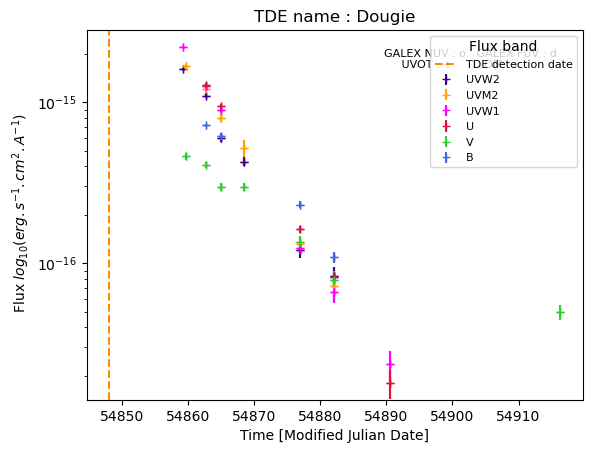

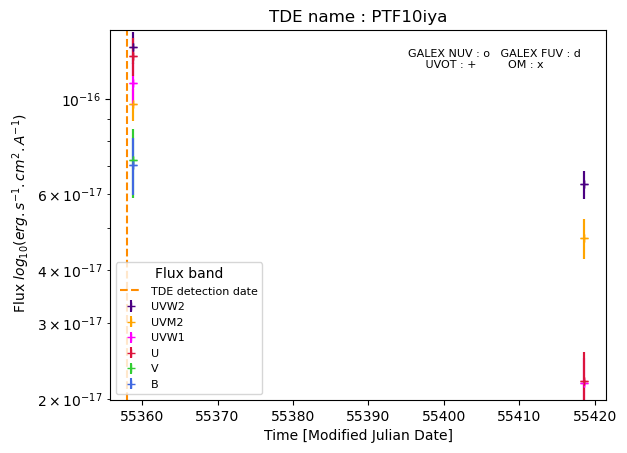

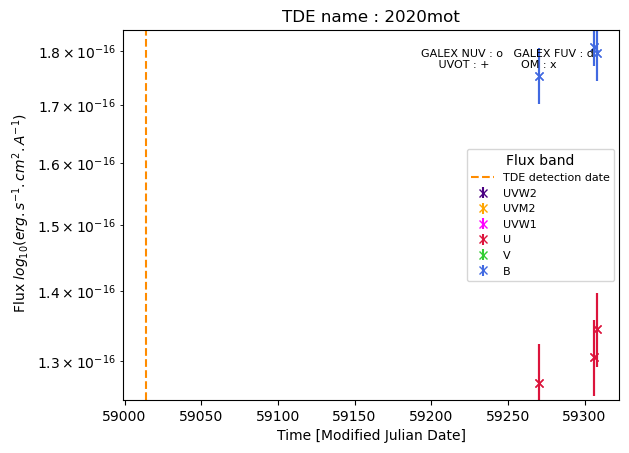

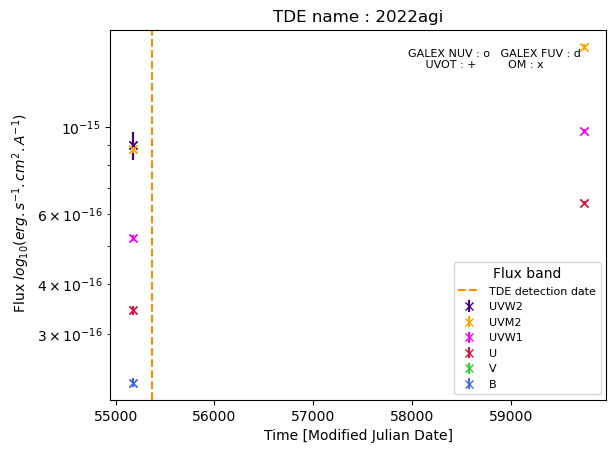

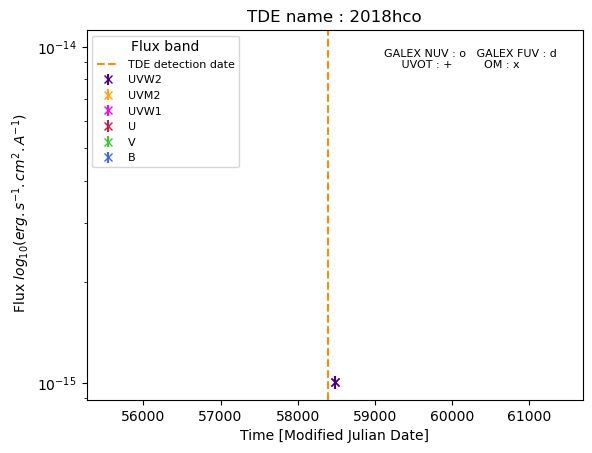

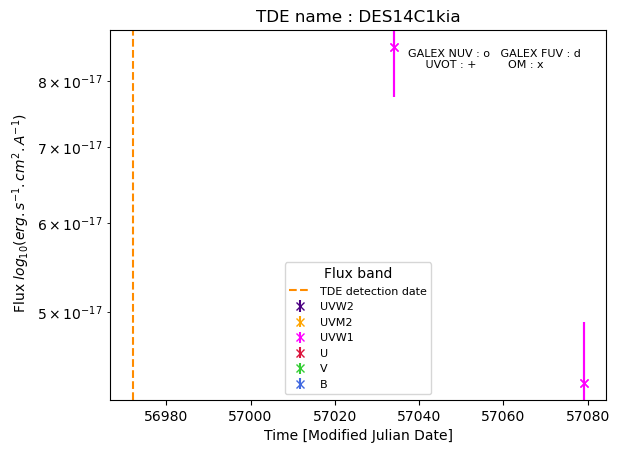

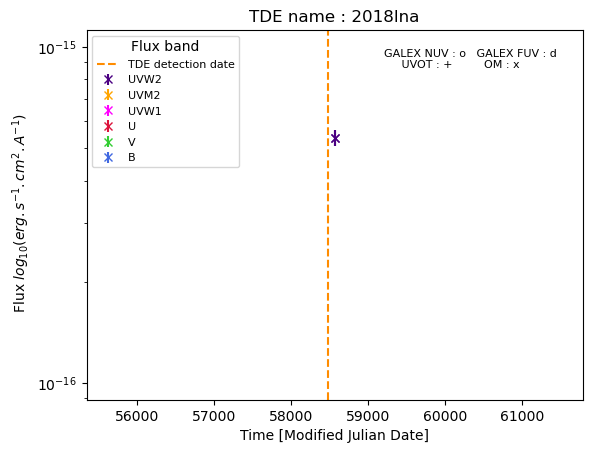

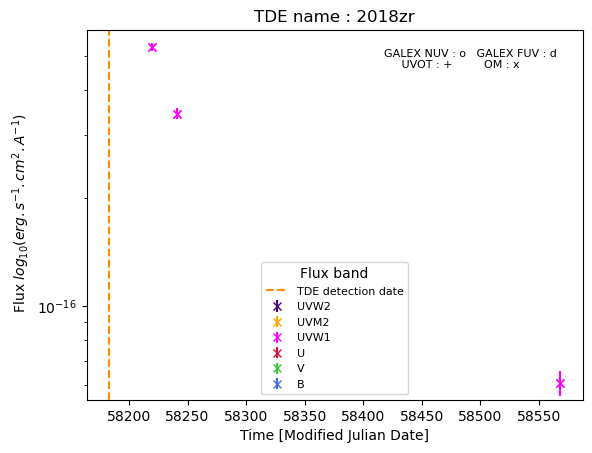

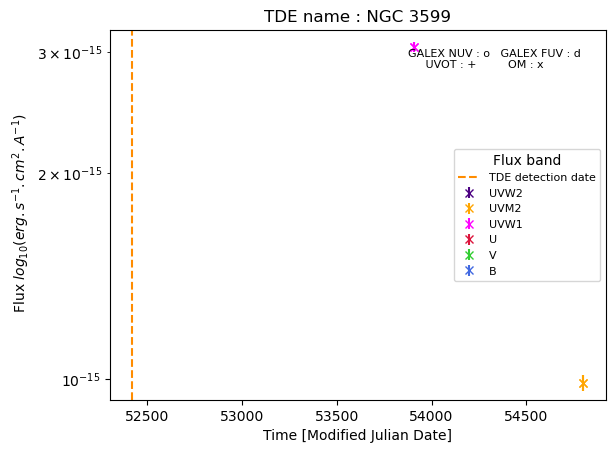

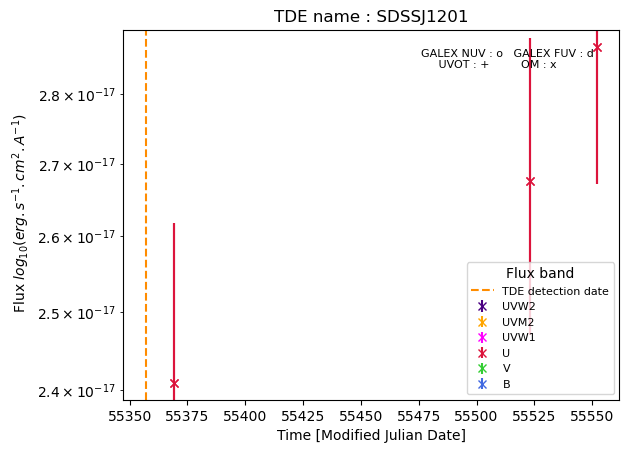

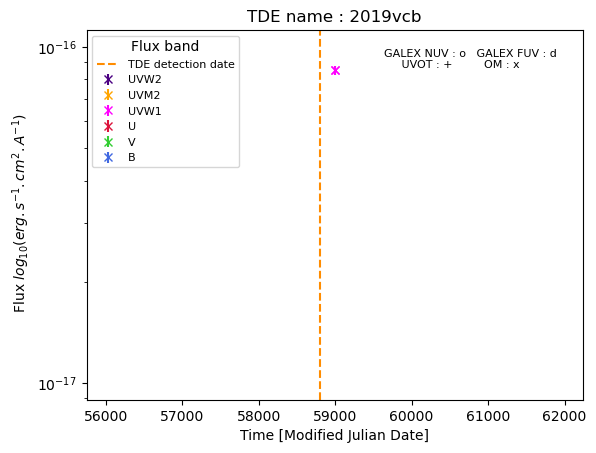

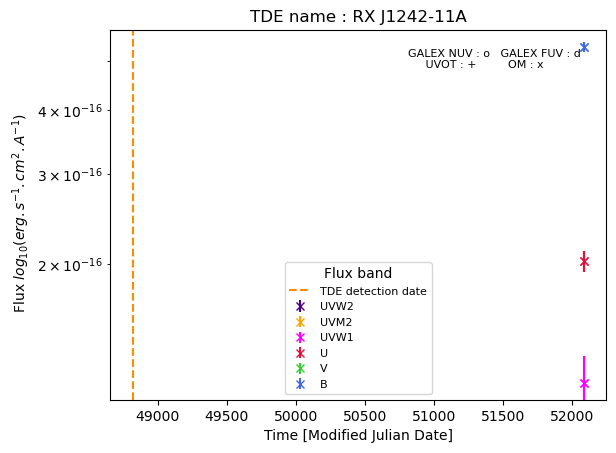

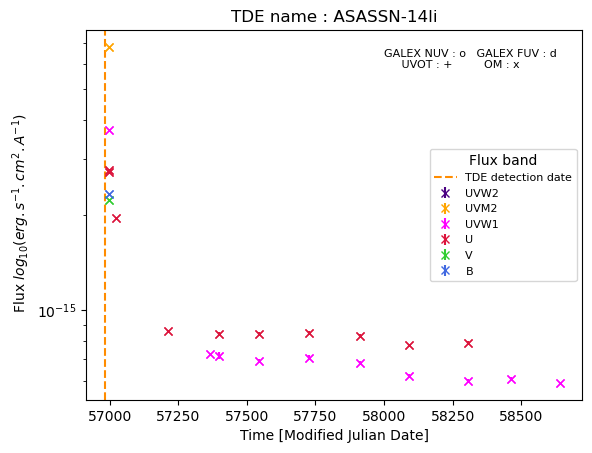

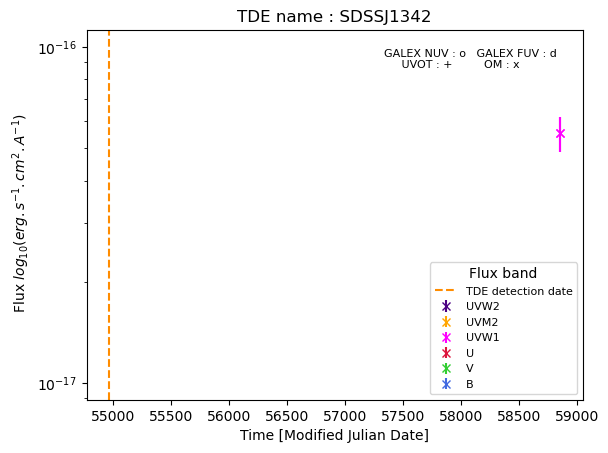

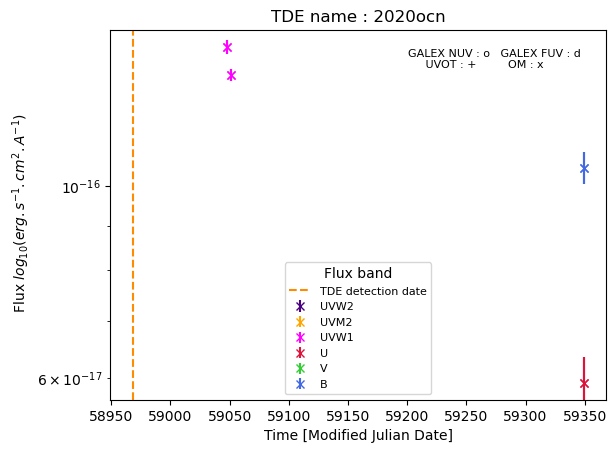

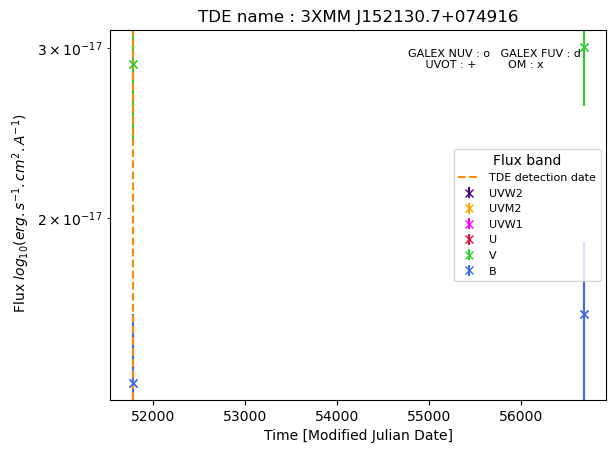

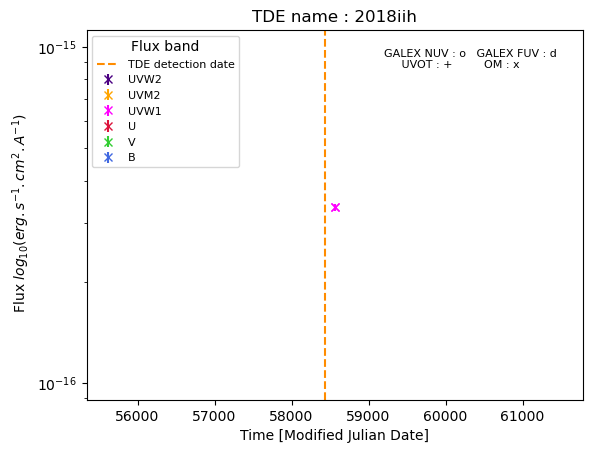

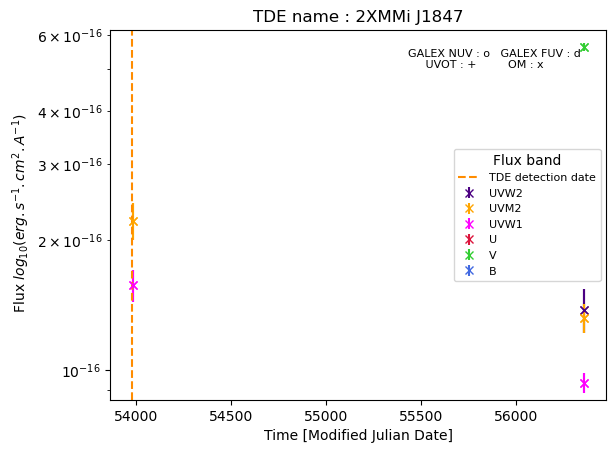

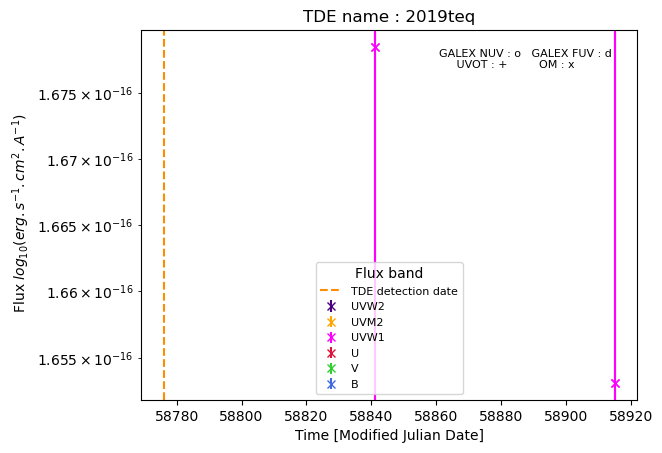

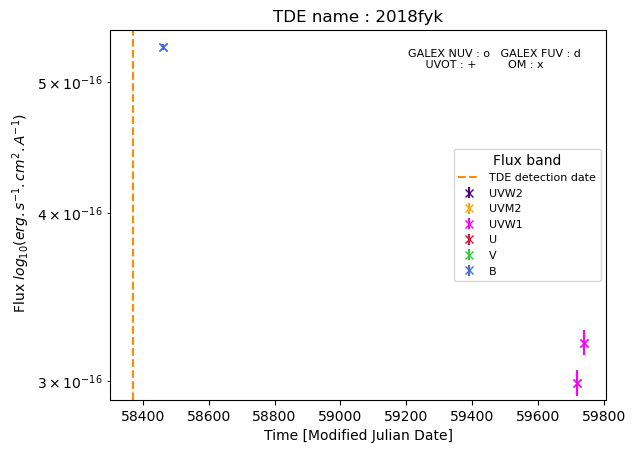

In [22]:
print_light_curve(df_merge,roots_tfm +'/TDE')

In [23]:
bla

NameError: name 'bla' is not defined

In [ ]:
df_entries[df_entries['RA'] == 182.199409]

In [24]:
df_tde = pd.read_csv(roots_tfm +'/TDE/TDE_match_UVOT_OM')
df_entries = pd.read_csv(roots_tfm +'/Entries_galaxies_more_than_2.csv')
df_tde_uvot = df_tde[df_tde['SRCNUM_1'] !=0]
df_tde_om = df_tde[df_tde['SRCNUM_2'] !=0]
df_merge_uvot = df_tde_uvot[['col1_1', 'SRCNUM_2', 'col1_2', 'MJD']].merge(df_entries,left_on='col1_1',right_on='SRCNUM_UVOT')
df_merge_uvot=df_merge_uvot.rename(columns={'col1_1': 'SRCNUM_1'})
df_merge_om = df_tde_om[['SRCNUM_1', 'SRCNUM_2', 'col1_2', 'MJD']].merge(df_entries,left_on='SRCNUM_2',right_on='SRCNUM_OM')
df_merge=pd.concat([df_merge_uvot, df_merge_om]).sort_values('SRCNUM_CUV').reset_index(drop=True)
df_merge=df_merge[df_merge['COUNT']>2]
df_merge.drop({'SRCNUM_1', 'SRCNUM_2'},axis=1)

/tmp/ipykernel_3032/2659835837.py:2: DtypeWarning: Columns (28,29,30,31,32,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_entries = pd.read_csv(roots_tfm +'/Entries_galaxies_more_than_2.csv')


,col1_2,MJD_x,SRCNUM_CUV,SRCNUM_OM,SRCNUM_UVOT,RA,DEC,POSERR,COUNT,W1mag,...,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD_y,OBSID,CAT
0,SDSSJ1201,55357.0,150880,3128579,2523391,180.400270,30.051397,0.501439,4,NaN,...,999,NaN,NaN,NaN,False,NaN,NaN,55523,555060401,OM
1,SDSSJ1201,55357.0,150880,3128579,2523391,180.400270,30.051397,0.501439,4,NaN,...,999,NaN,False,NaN,NaN,NaN,NaN,55398,31743005,UVOT
2,SDSSJ1201,55357.0,150880,3128579,2523391,180.400270,30.051397,0.501439,4,NaN,...,999,NaN,NaN,NaN,False,NaN,NaN,55369,555060301,OM
3,SDSSJ1201,55357.0,150880,3128579,2523391,180.400270,30.051397,0.501439,4,NaN,...,999,NaN,NaN,NaN,False,NaN,NaN,55552,555060501,OM
4,SDSSJ1342,54968.0,187028,3537841,2998036,205.685154,5.515645,0.488121,4,20.021180,...,999,NaN,NaN,True,NaN,NaN,NaN,58856,843440201,OM
5,SDSSJ1342,54968.0,187028,3537841,2998036,205.685154,5.515645,0.488121,4,20.021180,...,999,NaN,False,False,NaN,NaN,NaN,54971,90102003,UVOT
6,SDSSJ1342,54968.0,187028,3537841,2998036,205.685154,5.515645,0.488121,4,20.021180,...,999,False,False,False,False,NaN,NaN,54968,90102002,UVOT
7,SDSSJ1342,54968.0,187028,3537841,2998036,205.685154,5.515645,0.488121,4,20.021180,...,999,False,False,False,False,NaN,NaN,54966,90102001,UVOT
8,SDSSJ1342,54968.0,187028,3537841,2998036,205.685154,5.515645,0.488121,4,20.021180,...,0,NaN,NaN,NaN,NaN,NaN,NaN,54466,6378691551111941099,GALEX_NUV
9,SDSSJ1342,54968.0,187028,3537841,2998036,205.685154,5.515645,0.488121,4,20.021180,...,0,NaN,NaN,NaN,NaN,NaN,NaN,54466,6378691551111941099,GALEX_FUV


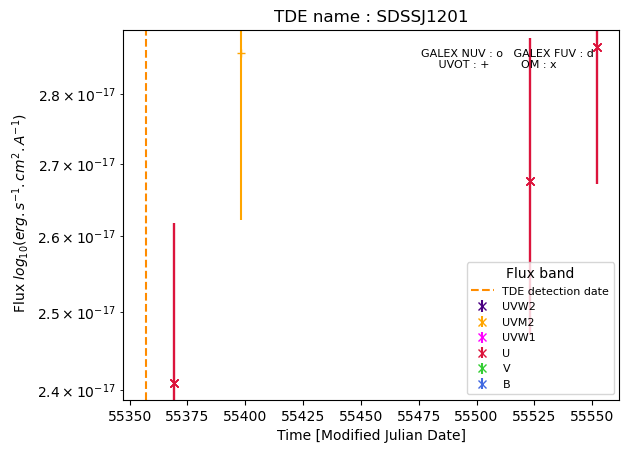

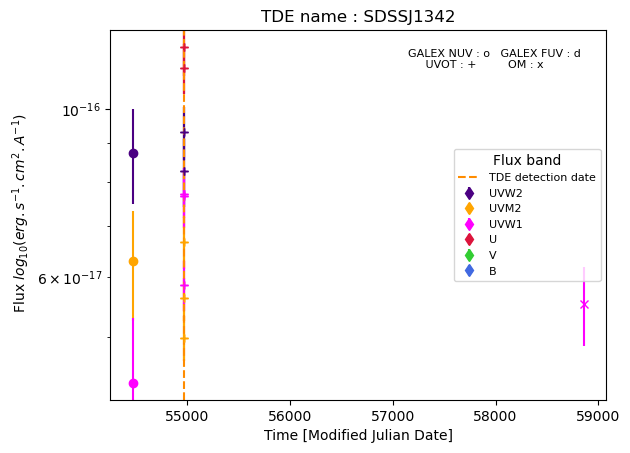

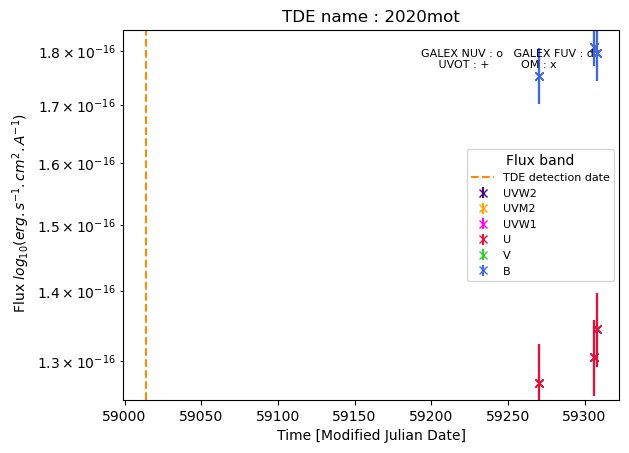

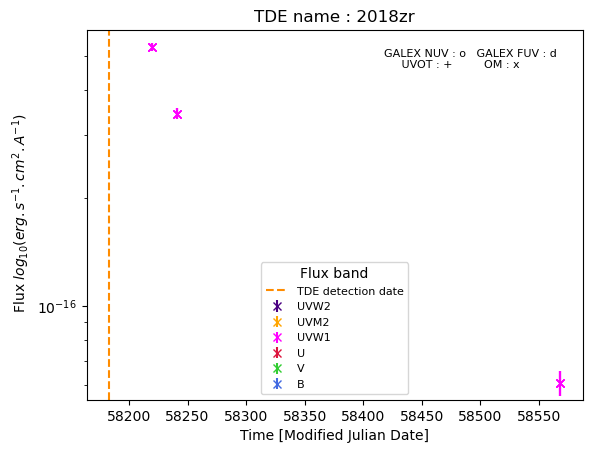

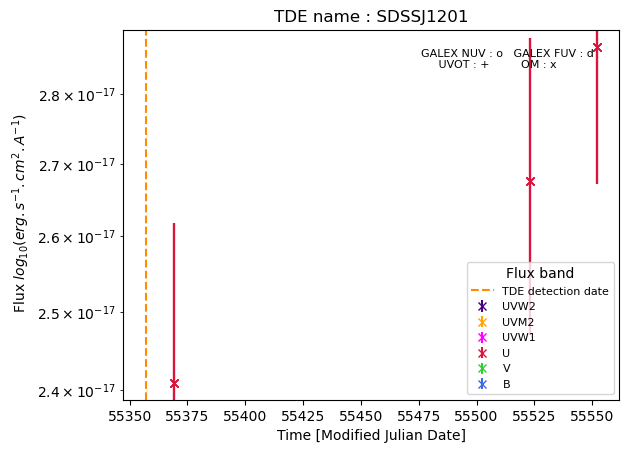

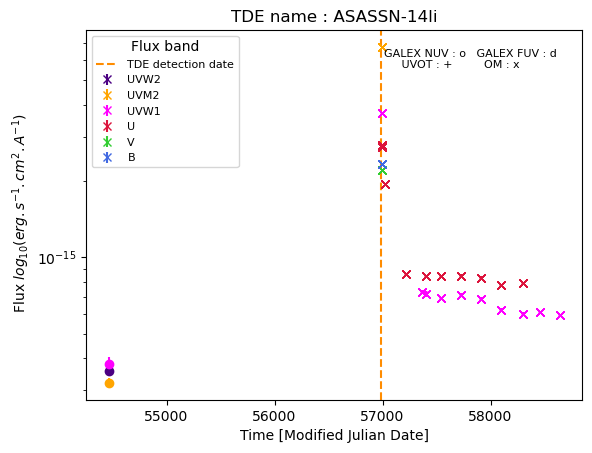

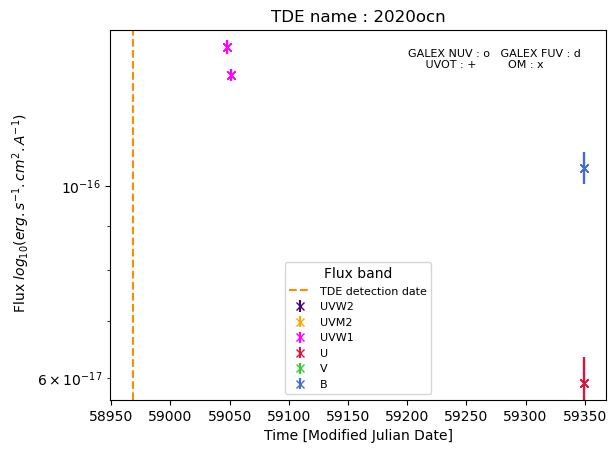

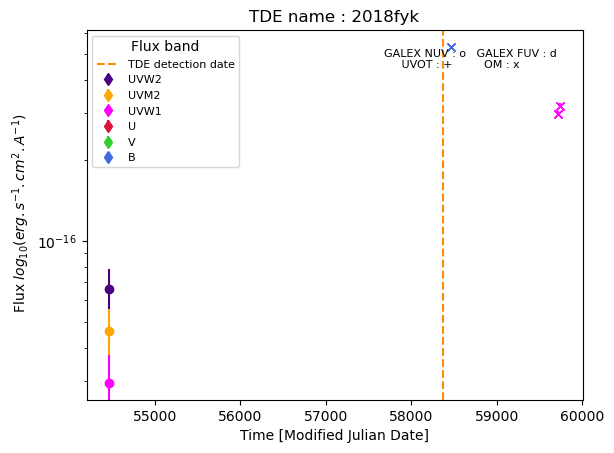

In [29]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fmt_dict = {'GALEX_NUV' : 'o','GALEX_FUV' : 'd', 'UVOT': '+', 'OM': 'x'}
color_dict = {'UVW2': 'indigo','UVW1': 'fuchsia','UVM2':'orange','U':'crimson','V':'limegreen','B':'royalblue'}
for tde in df_merge['SRCNUM_CUV'].unique():
    fig, ax =plt.subplots()
    ax.set_yscale('log')
    ind_select = (df_merge['SRCNUM_CUV'] == tde)
    for flux in ['UVW2','UVM2','UVW1','U','V','B']:
        flux_key = flux + "_FLUX"
        flux_err_key = flux_key + "_ERR"
        for cat in df_merge.loc[ind_select,'CAT']:
            ind = ((df_merge['SRCNUM_CUV'] == tde) & (df_merge['CAT'] == cat))
            ax.errorbar(df_merge.loc[ind,'MJD_y'],df_merge.loc[ind,flux_key],
                        yerr=df_merge.loc[ind,flux_err_key], \
                        fmt=fmt_dict[df_merge.loc[df_merge.loc[ind,'CAT'].index[0],'CAT']], color=color_dict[flux], \
                        ecolor=color_dict[flux])
        ax.errorbar(df_merge.loc[ind,'MJD_y'],df_merge.loc[ind,flux_key],
            yerr=df_merge.loc[ind,flux_err_key], \
            fmt=fmt_dict[df_merge.loc[df_merge.loc[ind,'CAT'].index[0],'CAT']], color=color_dict[flux], \
            ecolor=color_dict[flux],label=flux)
    ax.axvline(x=df_merge.loc[df_merge.loc[ind,'MJD_x'].index[0],'MJD_x'],color='darkorange',label='TDE detection date',linestyle='dashed')
    ax.set_xlabel('Time [Modified Julian Date]')
    ax.set_ylabel(' Flux ' +"$log_{10}(erg.s^{-1}.cm^{2}.A^{-1})$")
    ax.legend(loc='best',prop={'size': 8},title= "Flux band")
    ax.text(0.6, 0.95, 'GALEX NUV : ' + fmt_dict['GALEX_NUV'] + '   GALEX FUV : ' + fmt_dict['GALEX_FUV'] \
            + '\n     UVOT : ' + fmt_dict['UVOT'] + '         OM : ' + fmt_dict['OM'],\
    transform=ax.transAxes, fontsize=8, verticalalignment='top')
    plt.title("TDE name : " + df_merge.loc[df_merge.loc[ind,'col1_2'].index[0],'col1_2'])
    plt.show()
    fig.savefig(roots_tfm + '/TDE/Known TDE/'+ df_merge.loc[df_merge.loc[ind,'col1_2'].index[0],'col1_2']+'_light_curve2.png',\
                dpi=1200,bbox_inches="tight")
    plt.close()

In [ ]:
#df_merge.to_csv(roots_tfm + '/TDE/TDE_in_CUV.csv')

In [ ]:
df_merge.columns

In [ ]:
df_merge.loc[-1,:] = df_merge.loc[19,:]

In [ ]:
df_merge.loc[-1,:]

In [ ]:
df_merge.loc[-1,df_merge.columns[11:]] = df_merge.loc[35,df_merge.columns[11:]]

In [ ]:
df_merge.loc[-1,:]

In [ ]:
df_merge.loc[-1,'UVW1_FLUX_ERR'] = df_merge.loc[-1,'UVW1_FLUX']/10

In [ ]:
df_asass = df_merge[df_merge['col1_2'] == 'ASASSN-14li']

In [ ]:
df_asass[['MJD_y', 'UVW1_FLUX']]

In [ ]:
df_asass_2 = df_asass.drop(24)
df_asass_2['col1_2'] = 'ASASSN-14li_test'
df_asass_2['SRCNUM_CUV'] = 455441 
df_asass_2[['MJD_y', 'UVW1_FLUX']]

In [ ]:
df_test = pd.concat([df_asass, df_asass_2]).reset_index(drop=True)
df_test[['SRCNUM_CUV','MJD_y', 'UVW1_FLUX']]

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def print_light_curve(df):
    fmt_dict = {'GALEX_NUV' : 'o','GALEX_FUV' : 'd', 'UVOT': '+', 'OM': 'x'}
    color_dict = {'UVW2': 'indigo','UVW1': 'darkviolet','UVM2':'deeppink','U':'crimson','V':'limegreen','B':'royalblue'}
    for tde in df['SRCNUM_CUV'].unique():
        fig, ax =plt.subplots()
        ax.set_yscale('log')
        ind_select = (df['SRCNUM_CUV'] == tde)
        for flux in ['UVW2','UVM2','UVW1','U','V','B']:
            flux_key = flux + "_FLUX"
            flux_err_key = flux_key + "_ERR"
            if df.loc[ind_select,flux_key].shape[0]>0:
                for cat in df.loc[ind_select,'CAT']:
                    ind = ((df['SRCNUM_CUV'] == tde) & (df['CAT'] == cat))
                    ax.errorbar(df.loc[ind,'MJD_y'],df.loc[ind,flux_key],
                                yerr=df.loc[ind,flux_err_key], \
                                fmt=fmt_dict[df.loc[np.where(ind)[0][0],'CAT']], color=color_dict[flux], \
                                ecolor=color_dict[flux])
                ax.errorbar(df.loc[ind,'MJD_y'],df.loc[ind,flux_key],
                    yerr=df.loc[ind,flux_err_key], \
                    fmt=fmt_dict[df.loc[np.where(ind)[0][0],'CAT']], color=color_dict[flux], \
                    ecolor=color_dict[flux],label=flux)
        ax.axvline(x=df.loc[np.where(ind_select)[0][0],'MJD_x'],color='orange',label='TDE detection date')
        ax.set_xlabel('Time [Modified Julian Date]')
        ax.set_ylabel("Flux [" + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
        ax.legend(loc='lower right',prop={'size': 8},title= "Flux band")
        ax.text(0.6, 0.95, 'GALEX NUV : ' + fmt_dict['GALEX_NUV'] + '   GALEX FUV : ' + fmt_dict['GALEX_FUV'] \
                + '\n     UVOT : ' + fmt_dict['UVOT'] + '         OM : ' + fmt_dict['OM'],\
        transform=ax.transAxes, fontsize=8, verticalalignment='top')
        plt.title("TDE name : " + df.loc[np.where(ind_select)[0][0],'col1_2'])
        #fig.savefig(roots_tfm + '/TDE/'+df.loc[np.where(ind_select)[0][0],'col1_2']+'_flux_test.png',dpi=1200)
        plt.close()

In [ ]:
print_light_curve(df_test)

In [ ]:
#df_test.to_csv('TDE_test.csv')

In [ ]:
def variability(group):

    variability_dict ={}
    for flux in ['UVW2_FLUX','UVM2_FLUX','UVW1_FLUX']:  
        if group[flux].count()>1:
            idmax = group[flux].idxmax()
            idmin = group[flux].idxmin()
            variability_dict[flux] = 100 * (group.loc[idmax,flux]-group.loc[idmin,flux])/(group.loc[idmax,flux]* (group.loc[idmax,'MJD'] - group.loc[idmin,'MJD']))
        else:
            variability_dict[flux] = np.nan
    return pd.Series({
        'VAR_UVW2': variability_dict['UVW2_FLUX'],
        'VAR_UVM2': variability_dict['UVM2_FLUX'],
        'VAR_UVW1': variability_dict['UVW1_FLUX']
    })  

In [ ]:
df_test_uvw1 = df_test.dropna(subset='UVW1_FLUX').sort_values(['SRCNUM_CUV','MJD_y']).reset_index(drop=True)

In [ ]:
df_test_uvw1['UVW1_FLUX_prev'] = df_test_uvw1.groupby('SRCNUM_CUV')['UVW1_FLUX'].shift(-1)
df_test_uvw1['UVW1_FLUX_ERR_prev'] = df_test_uvw1.groupby('SRCNUM_CUV')['UVW1_FLUX_ERR'].shift(-1)

In [ ]:
df_test_uvw1['UVW1_var'] = (df_test_uvw1['UVW1_FLUX'] - df_test_uvw1['UVW1_FLUX_prev']) / np.sqrt( df_test_uvw1['UVW1_FLUX_ERR']**2 + df_test_uvw1['UVW1_FLUX_ERR_prev']**2)

In [ ]:
df_test_uvw1[['SRCNUM_CUV','MJD_y', 'UVW1_FLUX','UVW1_var']]

In [ ]:
df_test_uvw1['UVW1_FLUX_prev2'] = df_test_uvw1.groupby('SRCNUM_CUV')['UVW1_FLUX'].shift(-2)
df_test_uvw1['UVW1_FLUX_ERR_prev2'] = df_test_uvw1.groupby('SRCNUM_CUV')['UVW1_FLUX_ERR'].shift(-2)

In [ ]:
df_test_uvw1['UVW1_var2'] = (df_test_uvw1['UVW1_FLUX'] - df_test_uvw1['UVW1_FLUX_prev2']) / np.sqrt( df_test_uvw1['UVW1_FLUX_ERR']**2 + df_test_uvw1['UVW1_FLUX_ERR_prev2']**2)

In [ ]:
df_test_uvw1[['SRCNUM_CUV','MJD_y', 'UVW1_FLUX','UVW1_var','UVW1_var2']]

In [ ]:
df_test_uvw1['UVW1_var3'] = (df_test_uvw1['UVW1_FLUX_prev']/df_test_uvw1['UVW1_FLUX'])

In [ ]:
df_test_uvw1[['SRCNUM_CUV','MJD_y', 'UVW1_FLUX','UVW1_var','UVW1_var2','UVW1_var3']]